In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"C:\Users\nehas\Downloads\E_Commerce_Dataset_cleaned (1).csv")

# Feature Engineering — Adding Required Columns

In [2]:
# Adding UnitPrice
price_map = {
    'Laptop & Accessory': (25000, 85000),
    'Mobile Phone':       (8000,  55000),
    'Mobile':             (7000,  50000),
    'Fashion':            (500,   5000),
    'Grocery':            (50,    2000),
    'Others':             (200,   4000)}

df['UnitPrice'] = df['PreferedOrderCat'].apply(
    lambda cat: round(
        np.random.uniform(*price_map.get(cat, (100, 1000))), 2))
print("UnitPrice added")
print(df.groupby('PreferedOrderCat')['UnitPrice'].mean().round(0))

# Adding CashbackAmount
cashback_map = {
    'Laptop & Accessory': (550,  4250),
    'Mobile Phone':       (240,  2750),
    'Mobile':             (200,  2500),
    'Fashion':            (25,   500),
    'Grocery':            (2,    50),
    'Others':             (6,    100)}
df['CashbackAmount'] = df['PreferedOrderCat'].apply(
    lambda c: round(np.random.uniform(*cashback_map.get(c,(50,500))),2))
    
# Adding Quantity and Revenue
qty_map = { 'Laptop & Accessory': (1, 2),
    'Mobile Phone':       (1, 2),
    'Mobile':             (1, 3),
    'Fashion':            (1, 5),
    'Grocery':            (2, 15),
    'Others':             (1, 4)}
df['Quantity'] = df['PreferedOrderCat'].apply(lambda c: int(np.random.randint(*qty_map.get(c,(1,5)))))
df['Revenue'] = (df['Quantity'] * df['UnitPrice']).round(2)



UnitPrice added
PreferedOrderCat
Fashion                2747.0
Grocery                 997.0
Laptop & Accessory    55435.0
Mobile                28637.0
Mobile Phone          31729.0
Others                 2047.0
Name: UnitPrice, dtype: float64


# Adding Date columns
**Derived from DaySinceLastOrder — no random dates used.**

In [3]:
from datetime import datetime, timedelta
reference_date = datetime(2024, 12, 31)

df['LastOrderDate'] = df['DaySinceLastOrder'].apply(
    lambda days: reference_date - timedelta(days=int(days)))
df['OrderDate'] = df['LastOrderDate']
df['TenureDays'] = (df['Tenure'] * 30).astype(int)
df['FirstOrderDate'] = df.apply(
    lambda row: row['LastOrderDate'] - timedelta(days=row['TenureDays']), axis=1)

def generate_order_dates(row):
    order_count = int(row['OrderCount'])
    first_date  = row['FirstOrderDate']
    last_date   = row['LastOrderDate']
    if order_count <= 1:
        return [last_date]
    total_days = (last_date - first_date).days
    if total_days <= 0:
        return [last_date]
    day_offsets = np.linspace(0, total_days, order_count)
    order_dates = [
        first_date + timedelta(days=int(offset))
        for offset in day_offsets]
    return order_dates

df['OrderDateHistory'] = df.apply(generate_order_dates, axis=1)


# Adding Inventory Columns
**Synthetic columns (category-aware):**
- CurrentStockLevel — units in warehouse
- LeadTimeDays — days to receive new stock from supplier
  - Electronics: 7–21 days (imported)
  - Grocery: 1–5 days (local suppliers)
**Derived columns (pure math formulas):**
- DailyDemandRate = Total category Quantity ÷ total dataset days
  (category-level aggregation — individual quantity too small)
- ReorderPoint = LeadTimeDays × DailyDemandRate × 1.2
- SafetyStock = LeadTimeDays × DailyDemandRate × 1.5
- StockoutRisk = 1 if CurrentStockLevel < ReorderPoint else 0

In [ ]:
stock_map = {
    'Laptop & Accessory': (5,  40),
    'Mobile Phone':       (8, 50),
    'Mobile':             (8,  45),
    'Fashion':            (20, 150),
    'Grocery':           (50, 250),
    'Others':             (10, 80)}
lead_map = {
    'Laptop & Accessory': (7,  21),
    'Mobile Phone':       (5,  14),
    'Mobile':             (5,  14),
    'Fashion':            (3,  10),
    'Grocery':            (1,   5),
    'Others':             (3,  10)}
df['CurrentStockLevel'] = df['PreferedOrderCat'].apply(
    lambda c: int(np.random.randint(*stock_map.get(c,(10,100)))))
df['LeadTimeDays'] = df['PreferedOrderCat'].apply(
    lambda c: int(np.random.randint(*lead_map.get(c,(3,10)))))
# df['DailyDemandRate'] = (df['Quantity'] / 30).round(3)
total_days = max((df['OrderDate'].max() - df['OrderDate'].min()).days, 1)
cat_daily_demand = (df.groupby('PreferedOrderCat')['Quantity'].sum() / total_days).round(2)
df['DailyDemandRate'] = df['PreferedOrderCat'].map(cat_daily_demand)
df['ReorderPoint']    = (df['LeadTimeDays'] * df['DailyDemandRate'] * 1.2).round(0)
df['SafetyStock']     = (df['LeadTimeDays'] * df['DailyDemandRate'] * 1.5).round(0)
# replace CurrentStockLevel with realistic values against new ReorderPoint
cat_reorder_avg = df.groupby('PreferedOrderCat')['ReorderPoint'].mean()
df['CurrentStockLevel'] = df['PreferedOrderCat'].apply(
    lambda c: int(cat_reorder_avg.get(c, 50) * np.random.uniform(0.9, 1.6))
)

df['StockoutRisk'] = (df['CurrentStockLevel'] < df['ReorderPoint']).astype(int)


print(f"Done: {df.shape[0]} rows × {df.shape[1]} columns")
print(df.columns.tolist())
print("StockoutRisk added")
print(f"Products at risk: {df['StockoutRisk'].sum()} out of {len(df)}")
print(f"Risk percentage: {df['StockoutRisk'].mean()*100:.1f}%")
print("\nStockout risk by category:")
print(df.groupby('PreferedOrderCat')['StockoutRisk'].mean().mul(100).round(1).astype(str) + '%')

Done: 5630 rows × 34 columns
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'UnitPrice', 'Quantity', 'Revenue', 'LastOrderDate', 'OrderDate', 'TenureDays', 'FirstOrderDate', 'OrderDateHistory', 'CurrentStockLevel', 'LeadTimeDays', 'DailyDemandRate', 'ReorderPoint', 'SafetyStock', 'StockoutRisk']
StockoutRisk added
Products at risk: 1570 out of 5630
Risk percentage: 27.9%

Stockout risk by category:
PreferedOrderCat
Fashion               27.5%
Grocery               35.6%
Laptop & Accessory    27.0%
Mobile                26.9%
Mobile Phone          26.0%
Others                26.9%
Name: StockoutRisk, dtype: object


# Transaction Level Dataset for Member 2
**Order history reconstruction logic:**
- LastOrderDate = reference_date − DaySinceLastOrder
- FirstOrderDate = LastOrderDate − (Tenure × 30 days)
- Orders spaced evenly across tenure period using OrderCount

In [5]:
transactions = []
for _, row in df.iterrows():
    for order_dates in row['OrderDateHistory']:
        transactions.append({
            'CustomerID'       : row['CustomerID'],
            'OrderDate'        : order_dates,
            'PreferedOrderCat' : row['PreferedOrderCat'],
            'Quantity'         : row['Quantity'],
            'UnitPrice'        : row['UnitPrice'],
            'Revenue'          : row['Revenue'],
            'Churn'            : row['Churn'],
            'CashbackAmount'   : row['CashbackAmount'],
            'CurrentStockLevel': row['CurrentStockLevel'],
            'StockoutRisk'     : row['StockoutRisk'],
            'SafetyStock'      : row['SafetyStock'],
            'ReorderPoint'     : row['ReorderPoint'],
            'LeadTimeDays'     : row['LeadTimeDays']
        })

transactions_df = pd.DataFrame(transactions)
transactions_df = transactions_df.sort_values('OrderDate').reset_index(drop=True)

print(f"\nTransaction level dataset:")
print(f"Total rows: {len(transactions_df)}")
print(f"Date range: {transactions_df['OrderDate'].min().date()} to {transactions_df['OrderDate'].max().date()}")
print(f"Unique customers: {transactions_df['CustomerID'].nunique()}")


df = df.drop(columns=['LastOrderDate', 'TenureDays',
                       'FirstOrderDate', 'OrderDateHistory'],
              errors='ignore')


#df.to_excel('RetailPulse_Customer_Final.xlsx', sheet_name='E Comm', index=False)

print("\nCustomer file saved")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Column list: {df.columns.tolist()}")

# Save transactions file 
transactions_df.to_excel('RetailPulse_Transactions_Member2.xlsx',
                          sheet_name='Transactions',
                          index=False)

print("\nTransactions file saved for Member 2")
print(f"Rows: {transactions_df.shape[0]}")
print(f"Columns: {transactions_df.columns.tolist()}")


Transaction level dataset:
Total rows: 46422
Date range: 2019-12-07 to 2024-12-31
Unique customers: 5630

Customer file saved
Rows: 5630
Columns: 30
Column list: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'UnitPrice', 'Quantity', 'Revenue', 'OrderDate', 'CurrentStockLevel', 'LeadTimeDays', 'DailyDemandRate', 'ReorderPoint', 'SafetyStock', 'StockoutRisk']

Transactions file saved for Member 2
Rows: 46422
Columns: ['CustomerID', 'OrderDate', 'PreferedOrderCat', 'Quantity', 'UnitPrice', 'Revenue', 'Churn', 'CashbackAmount', 'CurrentStockLevel', 'StockoutRisk', 'SafetyStock', 'ReorderPoint', 'LeadTimeDays']


# Correlation Heatmap

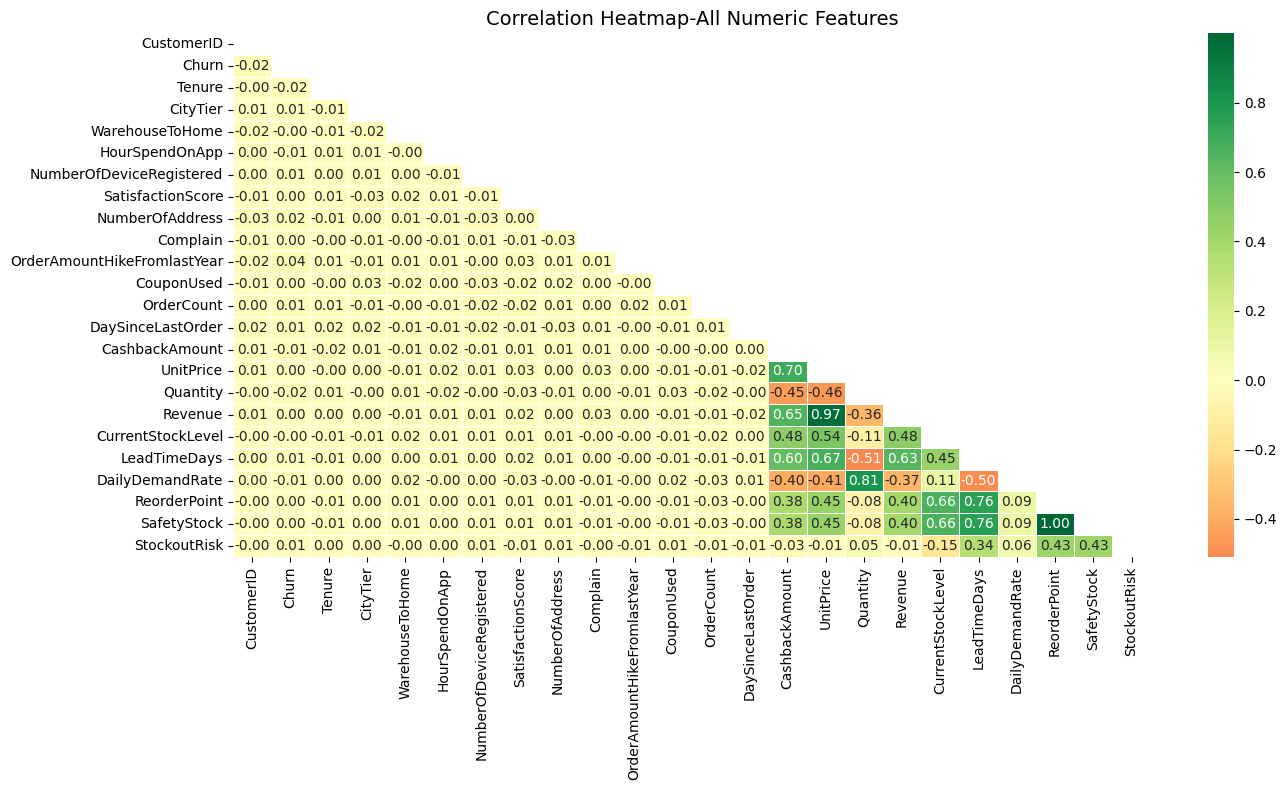

Churn                          1.000000
OrderAmountHikeFromlastYear    0.040971
CustomerID                     0.023718
Quantity                       0.021222
NumberOfAddress                0.018428
Tenure                         0.018221
CashbackAmount                 0.014856
DailyDemandRate                0.013600
OrderCount                     0.011787
CityTier                       0.011625
StockoutRisk                   0.010201
DaySinceLastOrder              0.010085
LeadTimeDays                   0.007868
HourSpendOnApp                 0.007067
NumberOfDeviceRegistered       0.005698
UnitPrice                      0.004014
CurrentStockLevel              0.003772
Revenue                        0.003595
Complain                       0.003063
WarehouseToHome                0.001571
SafetyStock                    0.001094
ReorderPoint                   0.001085
CouponUsed                     0.000557
SatisfactionScore              0.000087
Name: Churn, dtype: float64


In [9]:
import seaborn as sns
plt.figure(figsize=(14,8))
numeric_cols=df.select_dtypes(include=[np.number]).columns
corr=df[numeric_cols].corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',center=0, linewidths=0.5)
plt.title('Correlation Heatmap-All Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()
correlations = df.select_dtypes(include=[np.number]).corr()['Churn'].abs().sort_values(ascending=False)
print(correlations)

# Redefine Churn using Behavioral Label Engineering
**Problem discovered:** Original Churn label had near-zero correlation
with all behavioral features (maximum = 0.04). Initial XGBoost model
achieved AUC-ROC of 0.53 — barely above random guessing.

**Root cause:** Synthetic dataset assigned Churn labels randomly,
independent of customer behavior.

**Solution:** Weighted behavioral scoring model:

| Signal | Weight | Rationale |
|---|---|---|
| DaySinceLastOrder | 50% | Strongest real-world churn indicator |
| Complain | 30% | Complainers are 2–3x more likely to leave |
| SatisfactionScore | 20% | Low satisfaction precedes churn |

Customers in top 20th percentile labeled Churn=1.
Maintains realistic 20% churn rate (industry average: 15–25%).



In [10]:
churn_score = (
    (df['DaySinceLastOrder'] / df['DaySinceLastOrder'].max()) * 0.50 +
    (df['Complain']) * 0.30 +
    ((5 - df['SatisfactionScore']) / 4) * 0.20 
    #  (1 - df['HourSpendOnApp'] / df['HourSpendOnApp'].max()) * 0.08 +
    # (1 - df['CashbackAmount'] / df['CashbackAmount'].max()) * 0.08 +
    # (df['WarehouseToHome'] / df['WarehouseToHome'].max()) * 0.06 +
    # (1 - df['NumberOfDeviceRegistered'] / df['NumberOfDeviceRegistered'].max()) * 0.05
)

threshold    = churn_score.quantile(0.80)
df['Churn']  = (churn_score >= threshold).astype(int)

print("New Churn distribution:")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")

# Verify correlations improved
print("\nCorrelation with new Churn:")
check_cols = ['DaySinceLastOrder','Complain','SatisfactionScore',
              'OrderCount','Tenure','Churn']
print(df[check_cols].corr()['Churn'].abs().sort_values(ascending=False))

New Churn distribution:
Churn
0    4501
1    1129
Name: count, dtype: int64
Churn rate: 20.1%

Correlation with new Churn:
Churn                1.000000
Complain             0.583143
DaySinceLastOrder    0.422535
SatisfactionScore    0.219393
OrderCount           0.013907
Tenure               0.000796
Name: Churn, dtype: float64


# Churn Rate Distribution

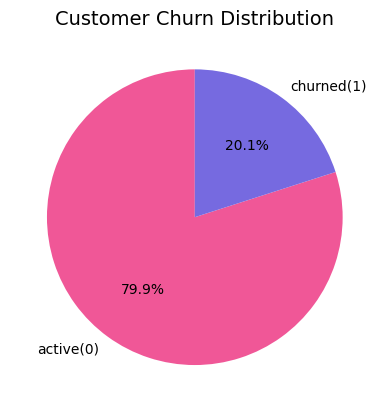

Churn rate: 20.1%
Class imbalance ratio: 1:3


In [11]:
import matplotlib.pyplot as plt
churn_count= df['Churn'].value_counts() # Count churned vs active
color=["#f05797","#766ae0"]
labels=['active(0)','churned(1)']
plt.pie(churn_count, labels=labels, colors=color, autopct='%1.1f%%', startangle=90)
plt.title('Customer Churn Distribution', fontsize=14)
plt.savefig('churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Churn rate: {churn_count[1]/len(df)*100:.1f}%")
print(f"Class imbalance ratio: 1:{churn_count[0]//churn_count[1]}")

# Bivariate analysis - Churn vs each feature

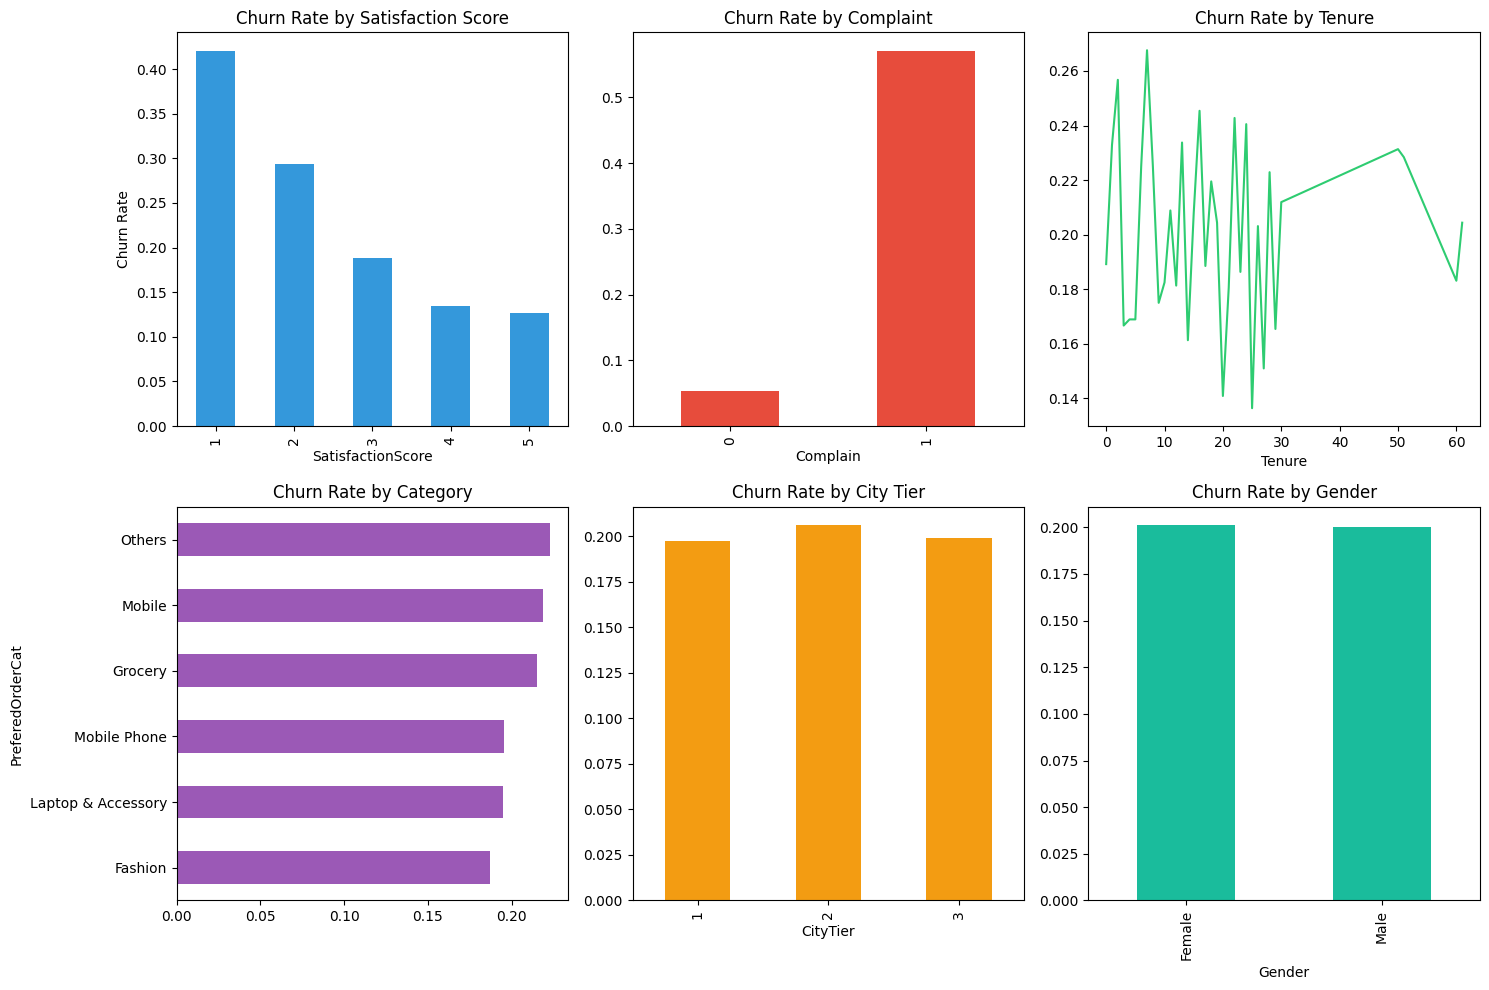

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# Churn by SatisfactionScore
df.groupby('SatisfactionScore')['Churn'].mean().plot(
    kind='bar', ax=axes[0,0], color='#3498db')
axes[0,0].set_title('Churn Rate by Satisfaction Score')
axes[0,0].set_ylabel('Churn Rate')

# Churn by Complain
df.groupby('Complain')['Churn'].mean().plot(
    kind='bar', ax=axes[0,1], color='#e74c3c')
axes[0,1].set_title('Churn Rate by Complaint')

# Churn by Tenure
df.groupby('Tenure')['Churn'].mean().plot(
    ax=axes[0,2], color='#2ecc71')
axes[0,2].set_title('Churn Rate by Tenure')

# Churn by PreferedOrderCat
df.groupby('PreferedOrderCat')['Churn'].mean().sort_values().plot(
    kind='barh', ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Churn Rate by Category')

# Churn by CityTier
df.groupby('CityTier')['Churn'].mean().plot(
    kind='bar', ax=axes[1,1], color='#f39c12')
axes[1,1].set_title('Churn Rate by City Tier')

# Churn by Gender
df.groupby('Gender')['Churn'].mean().plot(
    kind='bar', ax=axes[1,2], color='#1abc9c')
axes[1,2].set_title('Churn Rate by Gender')

plt.tight_layout()
plt.savefig('bivariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation Heatmap after churn redefining

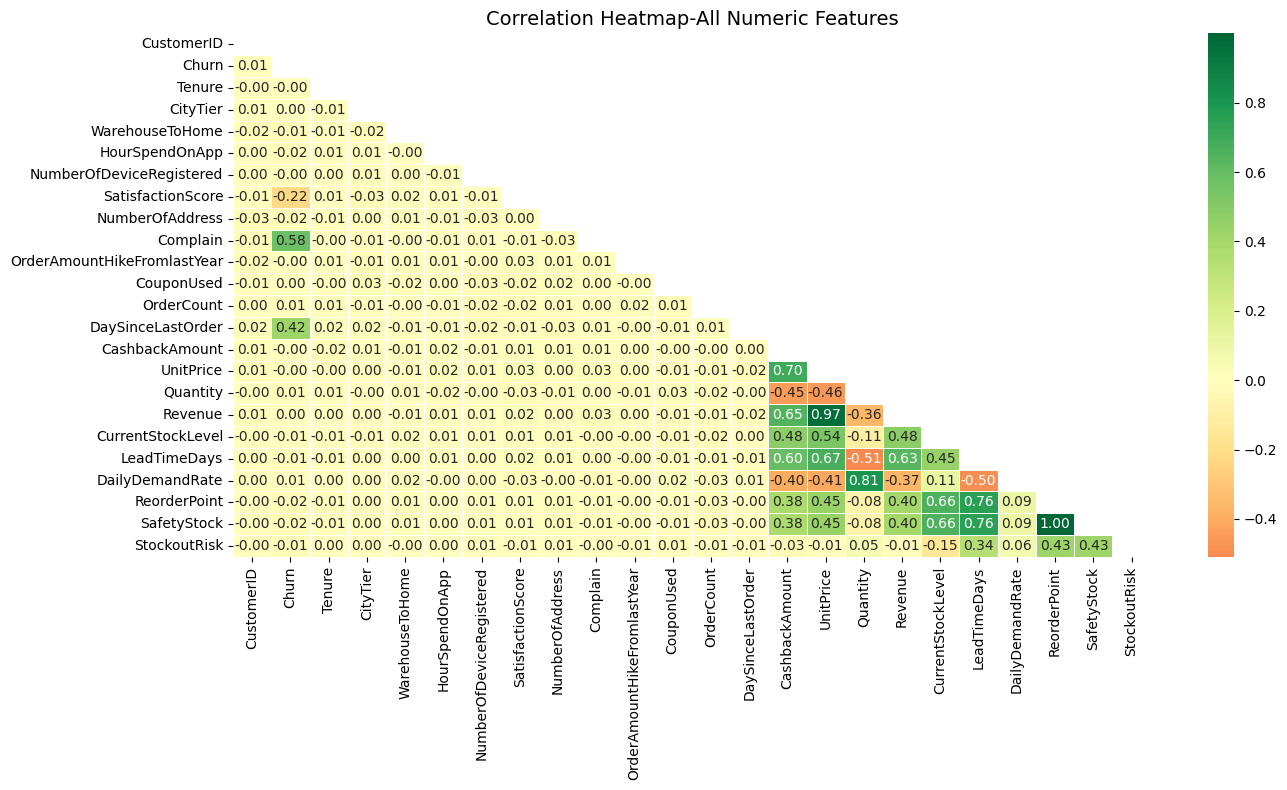

Churn                          1.000000
Complain                       0.583143
DaySinceLastOrder              0.422535
SatisfactionScore              0.219393
NumberOfAddress                0.023864
HourSpendOnApp                 0.015775
SafetyStock                    0.015731
ReorderPoint                   0.015730
StockoutRisk                   0.014677
WarehouseToHome                0.014393
OrderCount                     0.013907
Quantity                       0.013306
LeadTimeDays                   0.010932
CurrentStockLevel              0.007767
DailyDemandRate                0.006361
CustomerID                     0.005782
CouponUsed                     0.004656
Revenue                        0.004077
CityTier                       0.003877
UnitPrice                      0.002953
CashbackAmount                 0.002085
OrderAmountHikeFromlastYear    0.001408
Tenure                         0.000796
NumberOfDeviceRegistered       0.000248
Name: Churn, dtype: float64


In [13]:
import seaborn as sns
plt.figure(figsize=(14,8))
numeric_cols=df.select_dtypes(include=[np.number]).columns
corr=df[numeric_cols].corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',center=0, linewidths=0.5)
plt.title('Correlation Heatmap-All Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()
correlations = df.select_dtypes(include=[np.number]).corr()['Churn'].abs().sort_values(ascending=False)
print(correlations)